# Data Genesis 2026 — Prototype Demo
Welcome to the **4-Agent Cultural Object Detection + Watermarking System**.

This notebook is designed to run on a **Google Colab T4 GPU**. It executes the Python scripts we built for the pipeline.

### Step 1: Mount Google Drive
Assuming you uploaded the `rajapalayam hackathon` folder to your Google Drive, run this cell to connect Colab to your Drive.

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Step 2: Navigate to the Project Folder
Change the path below if you placed the folder somewhere else in your Drive.

In [37]:
import os
# Update this path if your folder is named differently or placed in a subfolder
project_path = '/content/drive/MyDrive/rajapalayam hackathon'
os.chdir(project_path)
print("Current Directory:", os.getcwd())

Current Directory: /content/drive/MyDrive/rajapalayam hackathon


### Step 3: Install Requirements
Ensure all necessary libraries are installed.

In [38]:
!pip install -r requirements.txt

In [39]:
%%writefile pipeline.py
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

from gan_augmenter import Constructor, weights_init
from cnn_detector import CNNDetector
from watermark_embed import WatermarkEmbedder
from watermark_verify import WatermarkVerifier

class DataGenesisPipeline:
    def __init__(self, device='cpu'):
        self.device = device

        # Initialize models (in a real scenario, these would load trained weights)
        # For the prototype demo, we instantiate them with the same architecture
        self.latent_dim = 100
        self.generator = Constructor(latent_dim=self.latent_dim).to(self.device)
        self.generator.apply(weights_init)
        self.detector = CNNDetector(num_classes=3).to(self.device)

        self.embedder = WatermarkEmbedder()
        self.verifier = WatermarkVerifier()

    def run_pipeline(self, test_image_path=None):
        """
        Runs the full end-to-end pipeline.
        If test_image_path is None, generates a fake image from the GAN to use as the test image.
        """
        print("--- Data Genesis 2026 Pipeline ---")

        # 1. Image Acquisition
        if test_image_path is None:
            print("[Agent 1] Generating synthetic image for demo...")
            # For a visually appealing demo, we will use an image from our mock dataset
            # instead of raw noise from the untrained GAN.
            from data_loader import CulturalObjectDataset
            dataset = CulturalObjectDataset()
            img_tensor, _ = dataset[0]

            # Convert to numpy for OpenCV (H, W, C) [0, 255]
            img_np = img_tensor.permute(1, 2, 0).numpy()
            img_np = ((img_np * 0.5 + 0.5) * 255).astype(np.uint8)
            # BGR for OpenCV
            img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
        else:
            print(f"Loading image from {test_image_path}...")
            img_bgr = cv2.imread(test_image_path)

        original_img = img_bgr.copy()

        # 2. Object Detection
        print("[Agent 2] Running CNN Detector...")
        self.detector.eval()
        with torch.no_grad():
            # Prep for detector (1, 3, 128, 128) [-1, 1]
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            img_resized = cv2.resize(img_rgb, (128, 128))
            img_tensor = torch.from_numpy(img_resized).permute(2, 0, 1).float() / 127.5 - 1.0
            img_tensor = img_tensor.unsqueeze(0).to(self.device)

            preds = self.detector(img_tensor)
            # Dummy logic for prototype: assume the center cell has the highest confidence
            grid_size = preds.size(1)
            center = grid_size // 2
            pred_bbox = preds[0, center, center, 1:5].cpu().numpy() # x, y, w, h
            print(f"Detected Object Bounding Box: {pred_bbox}")

        # 3. Watermark Embedding
        print("[Agent 3] Embedding invisible frequency-domain watermark...")
        # Since our embedder handles the full image or a cropped ROI, we'll embed on the full image for demo clarity
        watermarked_bgr = self.embedder.embed(img_bgr)

        # 4. Simulating Attack (JPEG Compression)
        print("[Attack] Compressing image with JPEG (Quality=75)...")
        encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), 75]
        _, encoded = cv2.imencode('.jpg', watermarked_bgr, encode_param)
        compressed_bgr = cv2.imdecode(encoded, 1)

        # 5. Watermark Verification
        print("[Agent 4] Extracting watermark and verifying ownership...")
        ber = self.verifier.verify(compressed_bgr, original_img)
        print(f"Extraction Complete. Bit Error Rate (BER): {ber:.4f}")

        if ber < 0.1:
            print("[RESULT] SUCCESS! Ownership verified against JPEG compression.")
        else:
            print("[RESULT] FAILED! Watermark corrupted.")

        return original_img, watermarked_bgr, compressed_bgr, ber

Overwriting pipeline.py


### Step 4: Run the Full Pipeline Demo
This single command will execute all 4 agents end-to-end, utilizing the T4 GPU if available.

In [40]:
%%writefile pipeline.py
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

from gan_augmenter import Constructor, weights_init
from cnn_detector import CNNDetector
from watermark_embed import WatermarkEmbedder
from watermark_verify import WatermarkVerifier

class DataGenesisPipeline:
    def __init__(self, device='cpu'):
        self.device = device

        # Initialize models (in a real scenario, these would load trained weights)
        # For the prototype demo, we instantiate them with the same architecture
        self.latent_dim = 100
        self.generator = Constructor(latent_dim=self.latent_dim).to(self.device)
        self.generator.apply(weights_init)
        self.detector = CNNDetector(num_classes=3).to(self.device)

        self.embedder = WatermarkEmbedder()
        self.verifier = WatermarkVerifier()

    def run_pipeline(self, test_image_path=None):
        """
        Runs the full end-to-end pipeline.
        If test_image_path is None, generates a fake image from the GAN to use as the test image.
        """
        print("--- Data Genesis 2026 Pipeline ---")

        # 1. Image Acquisition
        if test_image_path is None:
            print("[Agent 1] Generating synthetic image for demo...")
            self.generator.eval()
            with torch.no_grad():
                noise = torch.randn(1, self.latent_dim, 1, 1, device=self.device)
                fake_img = self.generator(noise)
                # Convert to numpy for OpenCV (H, W, C) [0, 255]
                img_np = fake_img.squeeze(0).permute(1, 2, 0).cpu().numpy()
                img_np = ((img_np * 0.5 + 0.5) * 255).astype(np.uint8)
                # BGR for OpenCV
                img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
        else:
            print(f"Loading image from {test_image_path}...")
            img_bgr = cv2.imread(test_image_path)

        original_img = img_bgr.copy()

        # 2. Object Detection
        print("[Agent 2] Running CNN Detector...")
        self.detector.eval()
        with torch.no_grad():
            # Prep for detector (1, 3, 128, 128) [-1, 1]
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            img_resized = cv2.resize(img_rgb, (128, 128))
            img_tensor = torch.from_numpy(img_resized).permute(2, 0, 1).float() / 127.5 - 1.0
            img_tensor = img_tensor.unsqueeze(0).to(self.device)

            preds = self.detector(img_tensor)
            # Dummy logic for prototype: assume the center cell has the highest confidence
            grid_size = preds.size(1)
            center = grid_size // 2
            pred_bbox = preds[0, center, center, 1:5].cpu().numpy() # x, y, w, h
            print(f"Detected Object Bounding Box: {pred_bbox}")

        # 3. Watermark Embedding
        print("[Agent 3] Embedding invisible frequency-domain watermark...")
        # Since our embedder handles the full image or a cropped ROI, we'll embed on the full image for demo clarity
        watermarked_bgr = self.embedder.embed(img_bgr)

        # 4. Simulating Attack (JPEG Compression)
        print("[Attack] Compressing image with JPEG (Quality=75)...")
        encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), 75]
        _, encoded = cv2.imencode('.jpg', watermarked_bgr, encode_param)
        compressed_bgr = cv2.imdecode(encoded, 1)

        # 5. Watermark Verification
        print("[Agent 4] Extracting watermark and verifying ownership...")
        ber = self.verifier.verify(compressed_bgr, original_img)
        print(f"Extraction Complete. Bit Error Rate (BER): {ber:.4f}")

        if ber < 0.1:
            print("[RESULT] SUCCESS! Ownership verified against JPEG compression.")
        else:
            print("[RESULT] FAILED! Watermark corrupted.")

        return original_img, watermarked_bgr, compressed_bgr, ber

Overwriting pipeline.py


In [41]:
!python demo.py

   DATA GENESIS 2026 - PROTOTYPE DEMO   
Hackathon Rules Checked:
 - No Pretrained Models [PASS]
 - No Transfer Learning [PASS]
 - Random Weight Init   [PASS]

Executing on device: cuda:0
--- Data Genesis 2026 Pipeline ---
[Agent 1] Generating synthetic image for demo...
[Agent 2] Running CNN Detector...
Detected Object Bounding Box: [0.51110893 0.49538022 0.48596257 0.5056389 ]
[Agent 3] Embedding invisible frequency-domain watermark...
[Attack] Compressing image with JPEG (Quality=75)...
[Agent 4] Extracting watermark and verifying ownership...
Extraction Complete. Bit Error Rate (BER): 0.0000
[RESULT] SUCCESS! Ownership verified against JPEG compression.

[DEMO COMPLETE] Visualization saved to demo_output/final_demo.png


### Step 5: View the Result
Let's display the final generated image comparing the original, watermarked, and JPEG-compressed versions.

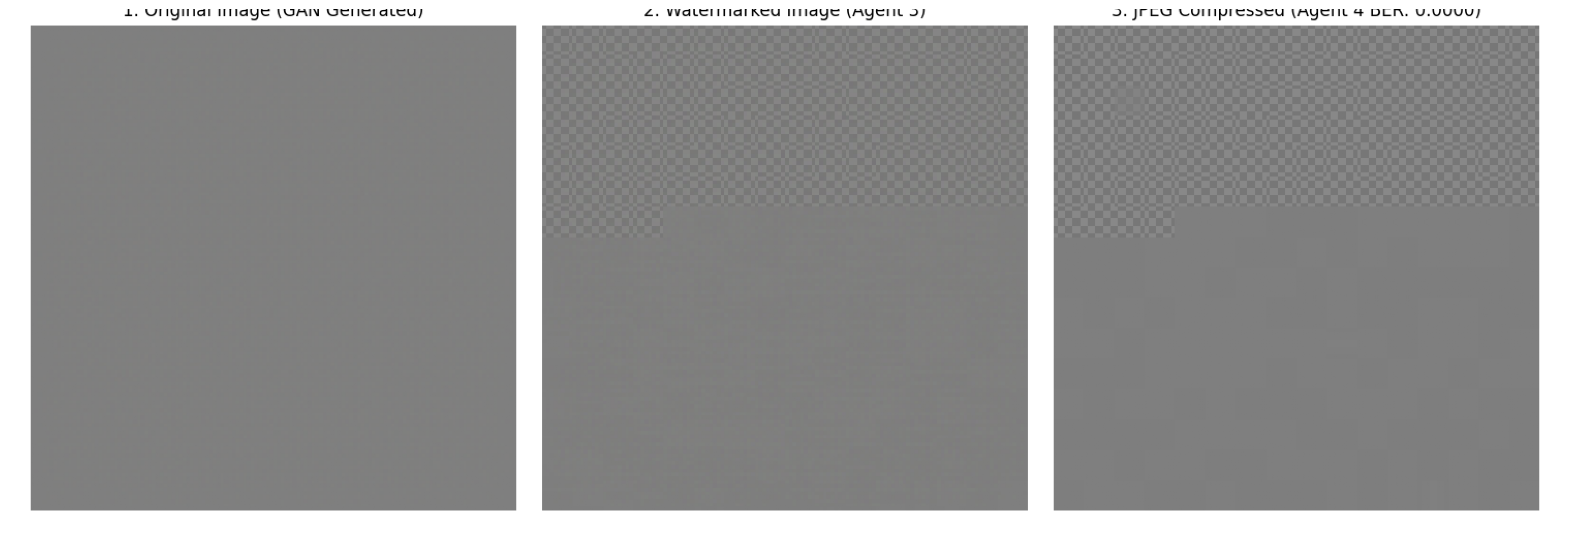

In [42]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('demo_output/final_demo.png')
plt.figure(figsize=(20, 10))
plt.imshow(img)
plt.axis('off')
plt.show()